In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv


In [ ]:
file_path = '/disk/gfs_atp/hekinc/2026_07_21_Warm_single_ended/alpine_warm_2.53V_400Hz_single_ended/RAW/DataR_CH0@DT5730S_59483_alpine_warm_2.53V_400Hz_single_ended.CSV'


# Pass 1: Read the first line to get the original keys
with open(file_path, 'r', encoding='utf-8') as f:
    original_keys = f.readline().strip().split(';')
    #rename the first SAMPLES key to SAMPLES1 to avoid duplicate column names
    original_keys[original_keys.index('SAMPLES')] = 'SAMPLES1'
    
    # Scan the rest of the file to find the longest row
    max_cols = max(len(line.strip().split(';')) for line in f)

# Generate new keys to fill the gap (e.g., if max_cols is 10 and original is 4)
if max_cols > len(original_keys):
    extra_keys_needed = max_cols - len(original_keys)
    for i in range(extra_keys_needed):
        original_keys.append(f"SAMPLES{i+2}")

# Pass 2: Let Pandas read the whole file using your newly extended keys
df = pd.read_csv(
    file_path, 
    sep=';', 
    names=original_keys, 
    skiprows=1,           # Skip the original broken header
    index_col=False
)

2496


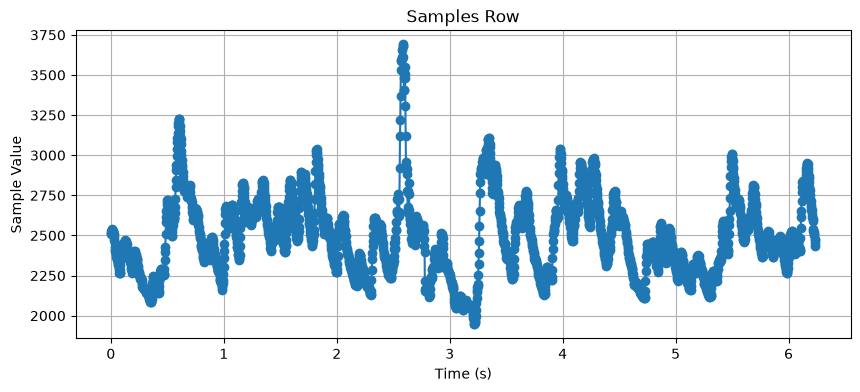

In [ ]:
# Grab only the 'SAMPLES' columns AND only the first 2 rows up front
df_samples_subset = df.filter(like='SAMPLES').head(1)

#convert to an np array for plotting
samples_array = df_samples_subset.iloc[0].values


len_samples = len(samples_array)

frequency = 250000000  # Frequency in Hz
period = 1 / frequency  # Period in seconds

print(len_samples)
time = np.arange(len_samples) * period  # Create a time array for plotting


df_samples = pd.DataFrame({
    'time_s': time,
    'signal_v': samples_array
})

plt.figure(figsize=(10, 4))
plt.plot(time, samples_array, marker='o')
plt.title(f'Samples Row')
plt.xlabel('Time (s)')
plt.ylabel('Sample Value')
plt.grid()
plt.show()

In [ ]:
print(np.mean(samples_array))  # Print the first row of samples

2492.6466346153848


In [ ]:
peak = df_samples['signal_v'].max()
peak_time = df_samples.loc[df_samples['signal_v'] == peak, 'time_s'].iloc[0]
total_avg = df_samples['signal_v'].mean()  # abritrarly selected baseline

# search the point where the signal reaches the total_avg after the maximum peak
post_peak_df = df_samples[(df_samples['time_s'] >= peak_time) & (df_samples['signal_v'] <= total_avg)]
if not post_peak_df.empty:
    # get the first point after the peak that drops to baseline
    peak_end = post_peak_df.iloc[0]

#else:
#don't save anything and skip it entirely
    #return np.nan


# do the same for the pre peak point earlier in time
pre_peak_df = df_samples[(df_samples['time_s'] <= peak_time) & (df_samples['signal_v'] <= total_avg)]

if not pre_peak_df.empty:
    # get the last point before the peak that was at baseline
    peak_start = pre_peak_df.iloc[-1]

#else:
#don't save anything and skip it entirely
    #return np.nan



# create a mask that removes the signal
pre_peak_bkg = (df_samples['time_s'] < peak_start['time_s'])
post_peak_bkg = (df_samples['time_s'] > peak_end['time_s'])

# call it background
background_df = df_samples[pre_peak_bkg]
background_df = background_df.rename(columns={'signal_v': 'pre_peak_bkg_v'})

# save the rest of the data as signal
signal_df = df_samples[~(post_peak_bkg & pre_peak_bkg)]

# average the background signal

background_avg = background_df['pre_peak_bkg_v'].mean()

# compute one sigma deviation of the background_avg
sigma = background_df['pre_peak_bkg_v'].std()

significant_signals = (signal_df['signal_v'] > background_avg + 3 * sigma)
signal_above_sigma = signal_df[significant_signals]
area = np.trapezoid(signal_above_sigma['signal_v'] - (background_avg + 3 * sigma), signal_above_sigma['time_s'])